In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Task 1:

In [2]:
df = pd.read_csv('letter-recognition.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   x-box   20000 non-null  int64 
 2   y-box   20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   high    20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   x-bar   20000 non-null  int64 
 7   y-bar   20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybr   20000 non-null  int64 
 12  xy2br   20000 non-null  int64 
 13  x-ege   20000 non-null  int64 
 14  xegvy   20000 non-null  int64 
 15  y-ege   20000 non-null  int64 
 16  yegvx   20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x-box,20000.0,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
y-box,20000.0,7.03550,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
high,20000.0,5.37245,2.261390,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
x-bar,20000.0,6.89760,2.026035,0.0,6.0,7.0,8.0,15.0
y-bar,20000.0,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,4.62860,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0
xybar,20000.0,8.28205,2.488475,0.0,7.0,8.0,10.0,15.0


In [4]:
le = LabelEncoder()
df['letter_enc'] = le.fit_transform(df['letter'])
print(dict(zip(le.classes_, le.transform(le.classes_))), "\n")

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25} 



In [5]:
X = df.drop(columns=['letter', 'letter_enc'])
y = df['letter_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train/Test shapes:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

Train/Test shapes:
X_train: (16000, 16)
X_test:  (4000, 16)
y_train: (16000,)
y_test:  (4000,)


# Task 2:

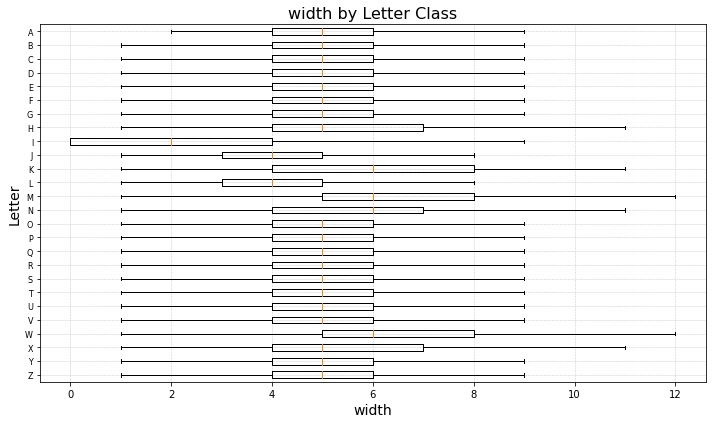

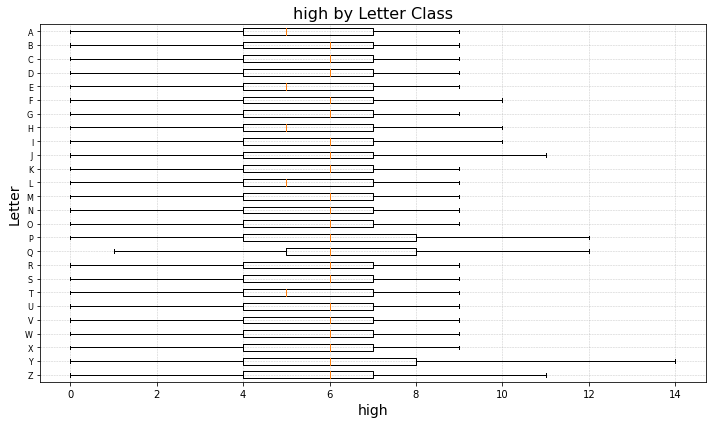

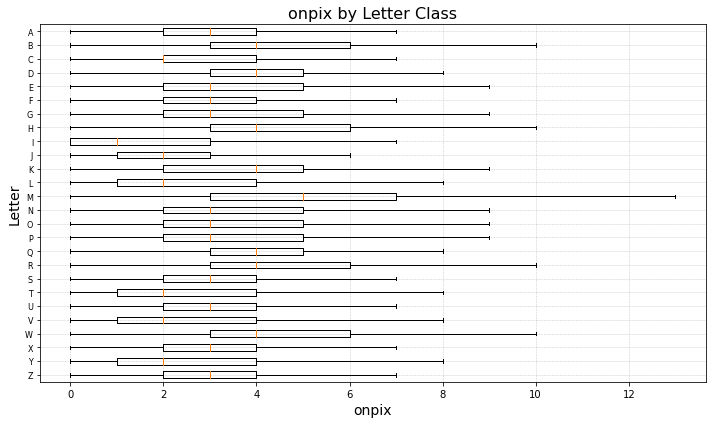

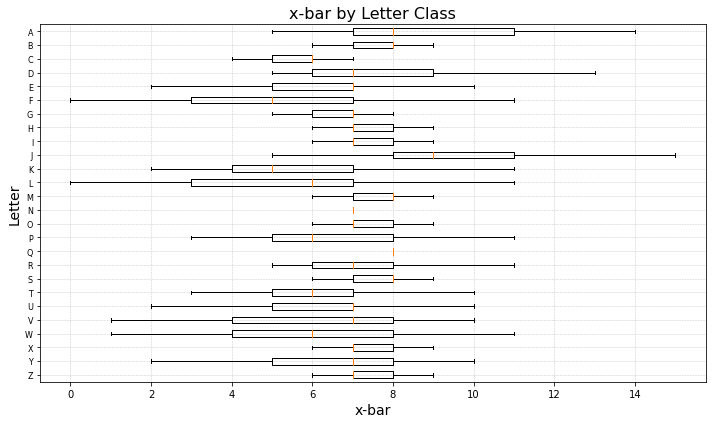

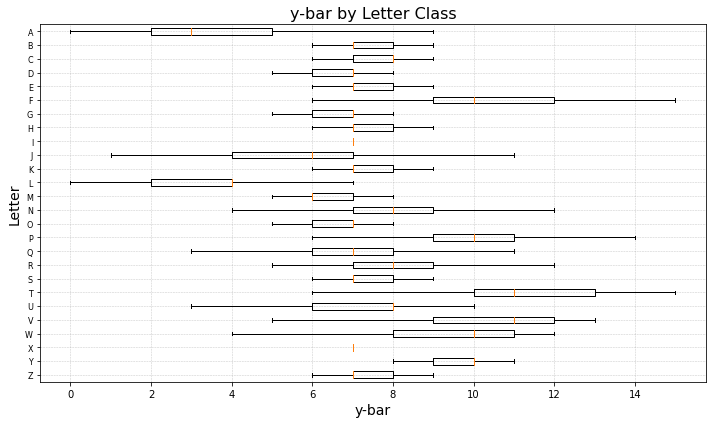

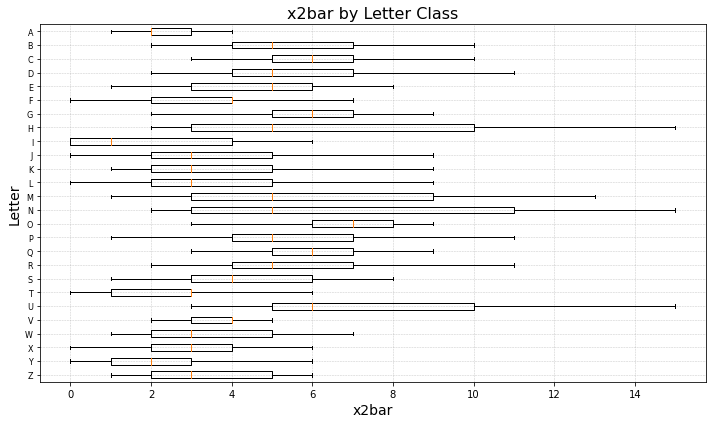

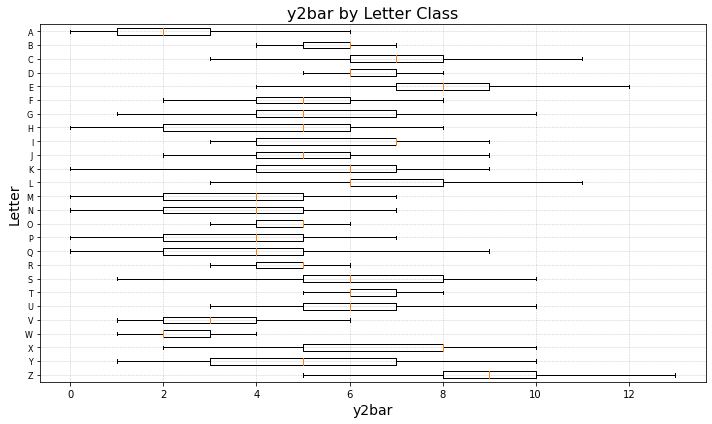

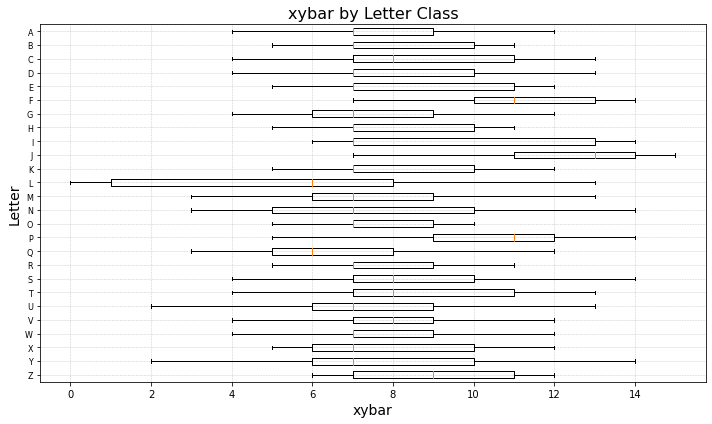

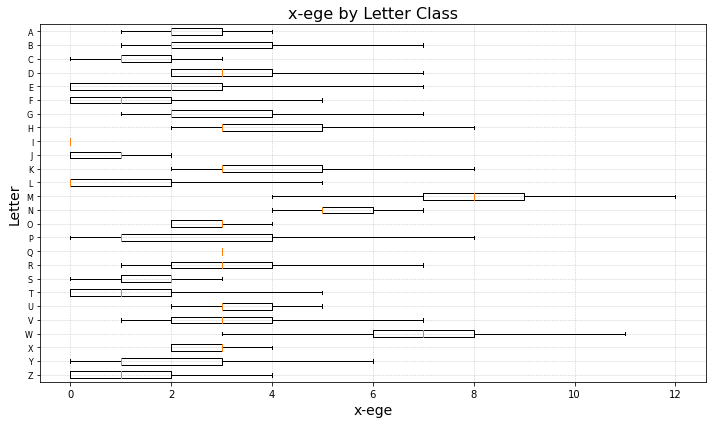

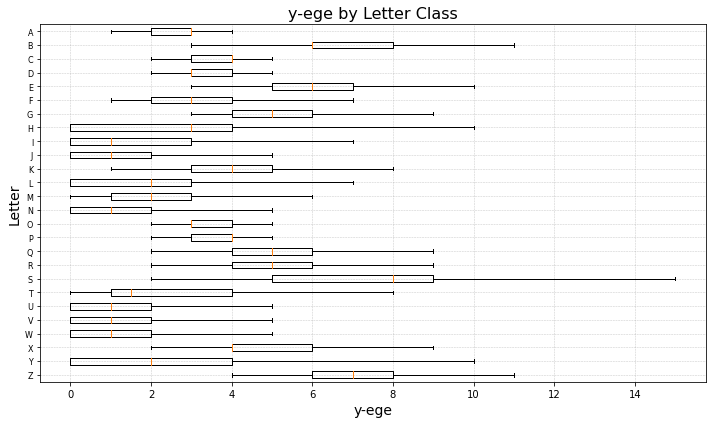

In [6]:
# Features to explore
features = ['width', 'high', 'onpix', 'x-bar', 'y-bar', 
            'x2bar', 'y2bar', 'xybar', 'x-ege', 'y-ege']

letters = sorted(df['letter'].unique())

# Prepare grouped data for boxplots
grouped = {feat: [df[df['letter'] == l][feat] for l in letters] for feat in features}

# Create boxplots
for feat in features:
    plt.figure(figsize=(10, 6))
    plt.boxplot(grouped[feat], vert=False, showfliers=False)
    plt.yticks(range(1, len(letters) + 1), letters, fontsize=8)
    plt.title(f'{feat} by Letter Class', fontsize=16)
    plt.xlabel(feat, fontsize=14)
    plt.ylabel('Letter', fontsize=14)
    plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.gca().invert_yaxis()  # Optional: A at top
    plt.tight_layout()
    plt.show()


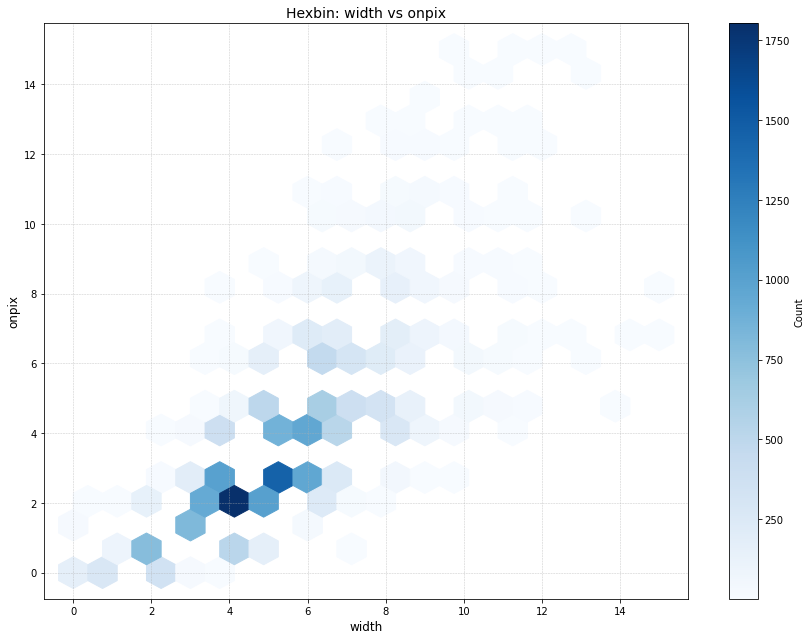

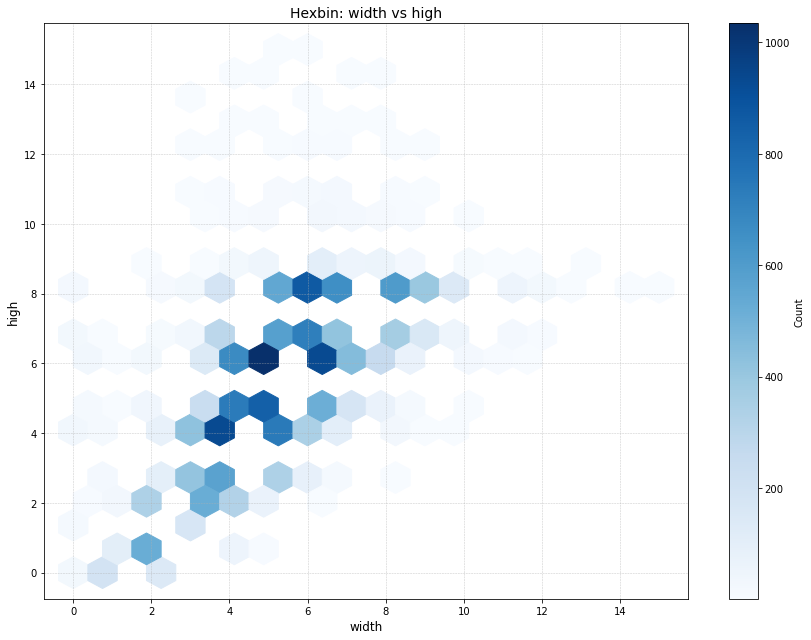

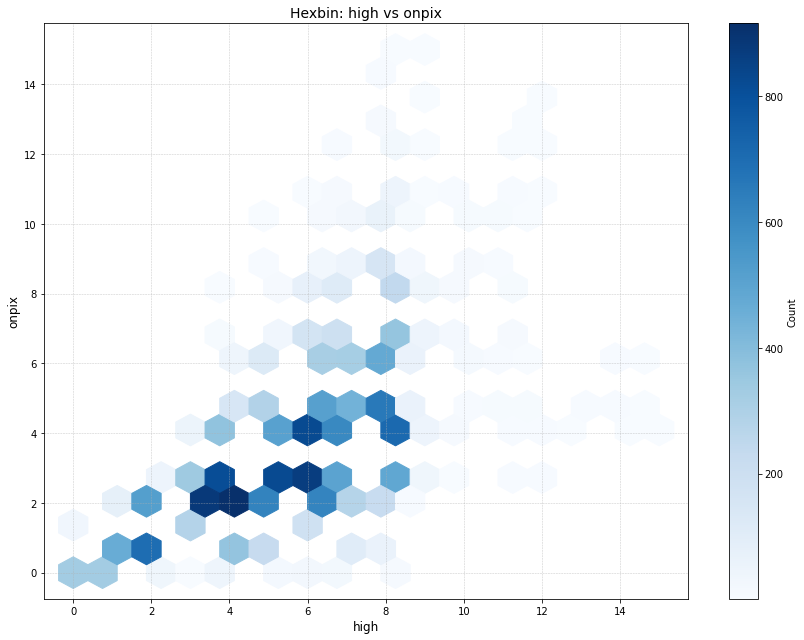

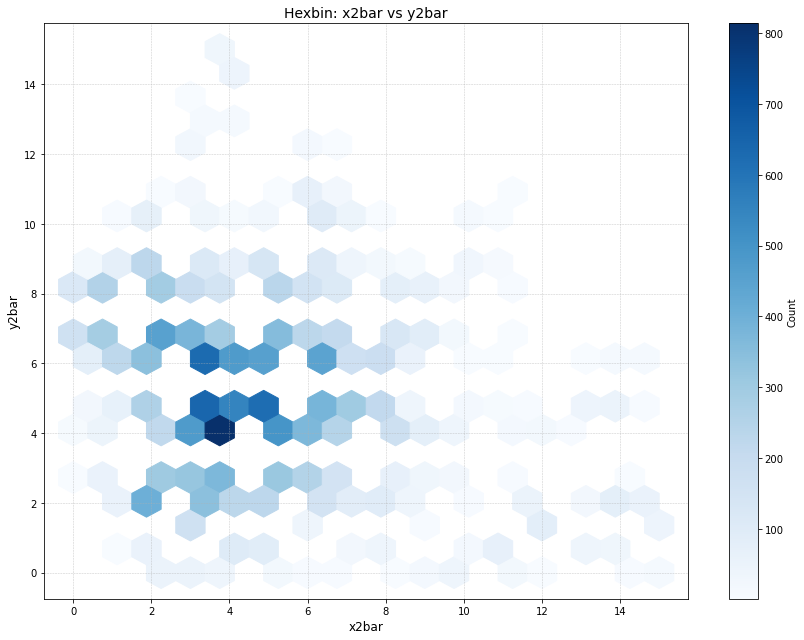

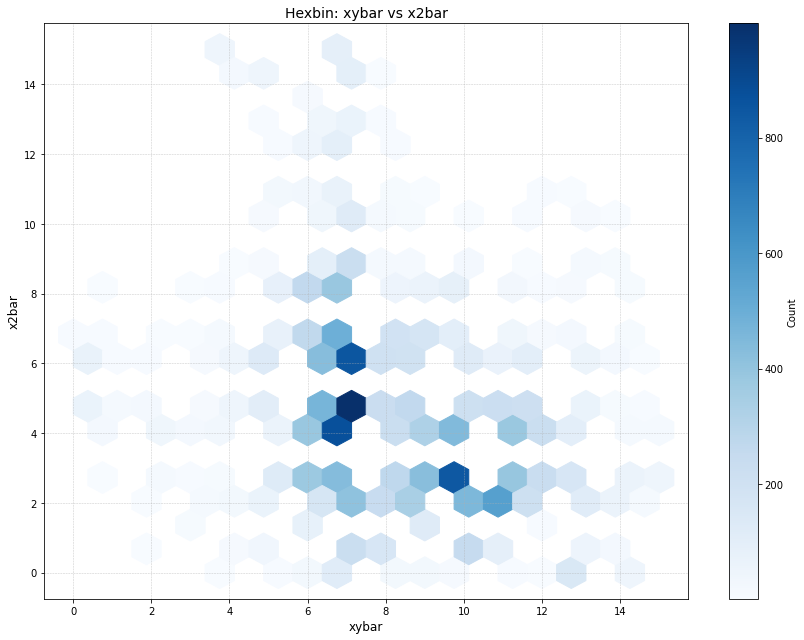

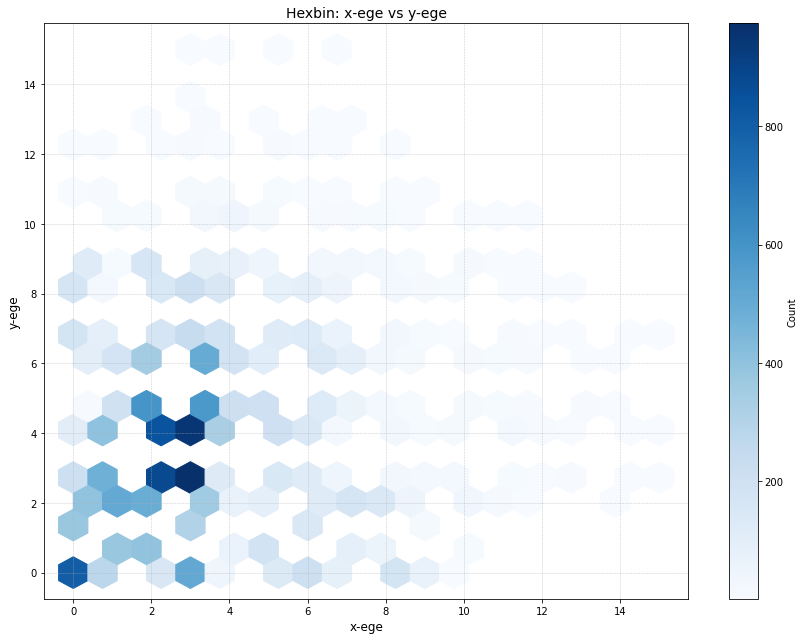

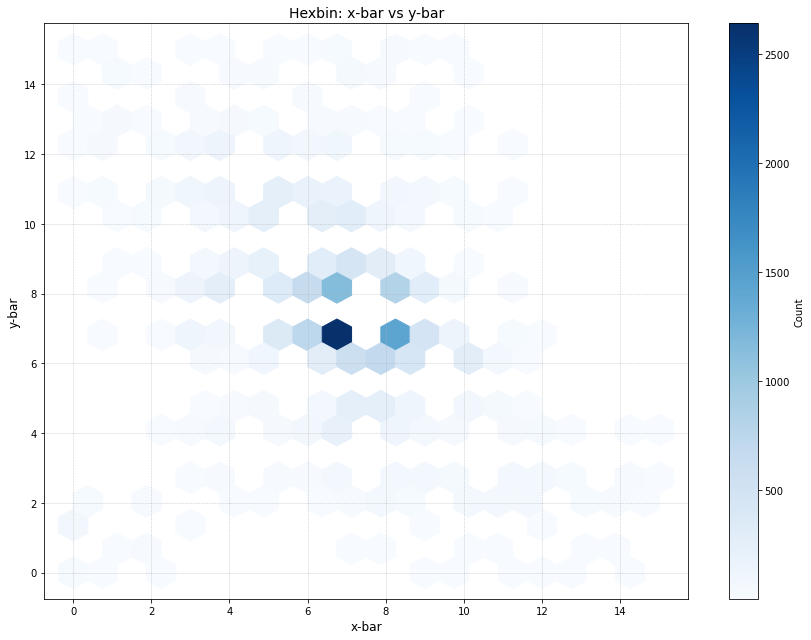

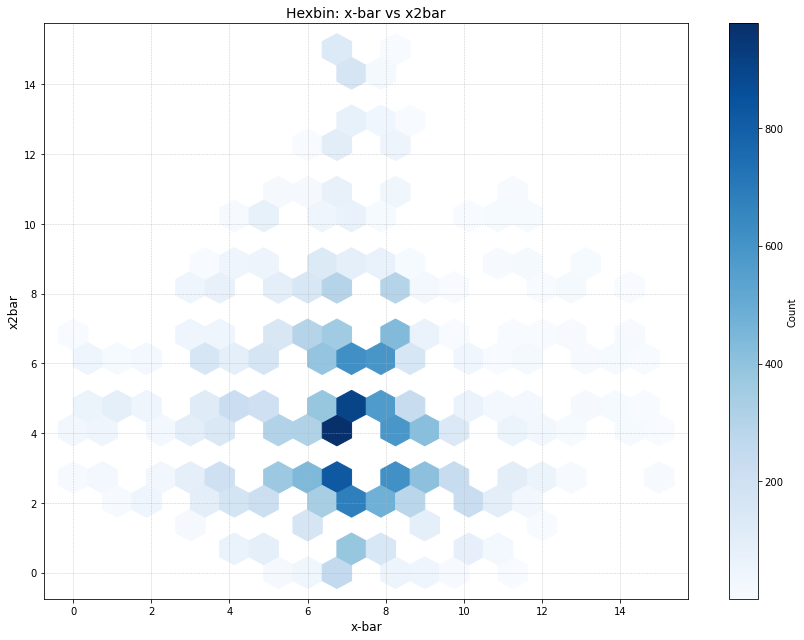

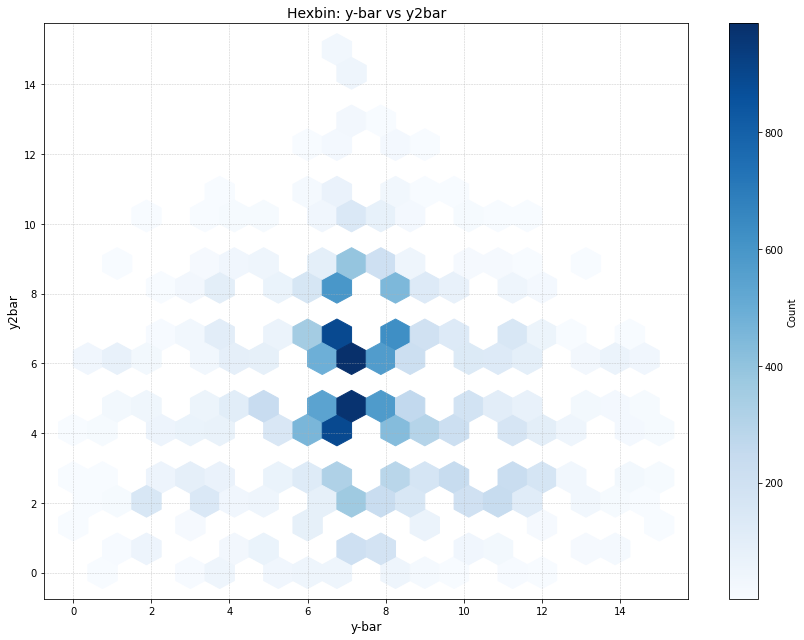

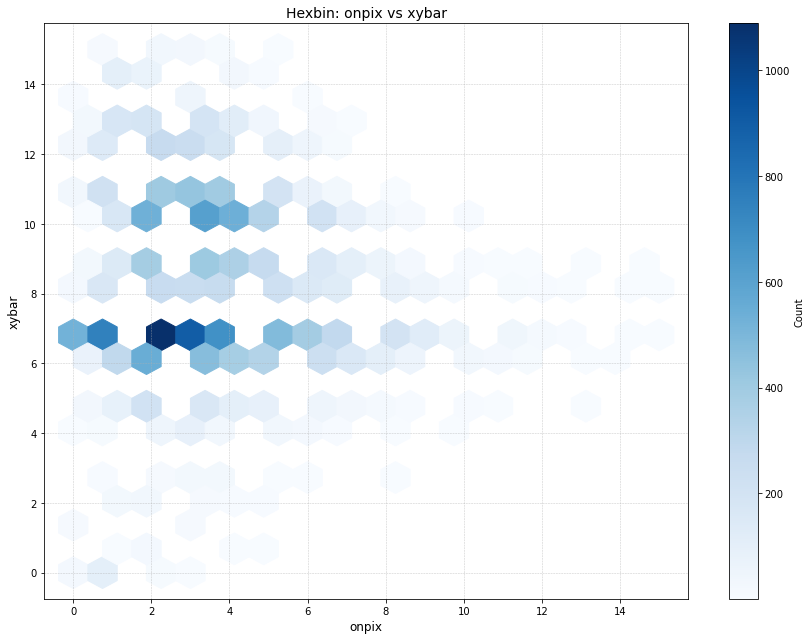

In [7]:
# Pairs of features for hexbin plots
pairs = [
    ('width', 'onpix'),
    ('width', 'high'),
    ('high', 'onpix'),
    ('x2bar', 'y2bar'),
    ('xybar', 'x2bar'),
    ('x-ege', 'y-ege'),
    ('x-bar', 'y-bar'),
    ('x-bar', 'x2bar'),
    ('y-bar', 'y2bar'),
    ('onpix', 'xybar')
]

# Create hexbin plots
for x_attr, y_attr in pairs:
    plt.figure(figsize=(12, 9))
    hb = plt.hexbin(
        df[x_attr],
        df[y_attr],
        gridsize=20,
        cmap='Blues',
        mincnt=1
    )
    plt.colorbar(hb, label='Count')
    plt.title(f'Hexbin: {x_attr} vs {y_attr}', fontsize=14)
    plt.xlabel(x_attr, fontsize=12)
    plt.ylabel(y_attr, fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


# Task 3:

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13]
}

grid_knn = GridSearchCV(
    pipe_knn, param_grid_knn, 
    cv=5, scoring='accuracy', n_jobs=1
)
grid_knn.fit(X_train, y_train)

print("Best k:", grid_knn.best_params_['knn__n_neighbors'])
y_pred_knn = grid_knn.predict(X_test)
print("KNN Test accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))



Best k: 3
KNN Test accuracy: 0.94375
              precision    recall  f1-score   support

           A       1.00      0.99      0.99       158
           B       0.87      0.94      0.90       153
           C       0.92      0.97      0.94       147
           D       0.86      0.99      0.92       161
           E       0.85      0.92      0.88       154
           F       0.90      0.90      0.90       155
           G       0.93      0.92      0.93       155
           H       0.90      0.88      0.89       147
           I       0.96      0.95      0.96       151
           J       0.96      0.95      0.96       149
           K       0.92      0.90      0.91       148
           L       0.99      0.97      0.98       152
           M       0.98      0.96      0.97       158
           N       0.95      0.93      0.94       157
           O       0.90      0.95      0.93       151
           P       0.97      0.91      0.94       160
           Q       0.98      0.94      0.96 

In [9]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ('scaler', StandardScaler()),  
    ('dt',     DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'dt__max_depth': [None,5,10,15,20,25,30],
    'dt__min_samples_split': [2,5,10, 20],
    'dt__min_samples_leaf': [1,2,5,10],}

grid_dt = GridSearchCV(
    pipe_dt, param_grid_dt,
    cv=5, scoring='accuracy',
    n_jobs=1
)
grid_dt.fit(X_train, y_train)

print("DT best params:", grid_dt.best_params_)
y_pred_dt = grid_dt.predict(X_test)
print("DT Test accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))


DT best params: {'dt__max_depth': 25, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
DT Test accuracy: 0.8755
              precision    recall  f1-score   support

           A       0.89      0.94      0.91       158
           B       0.82      0.82      0.82       153
           C       0.88      0.90      0.89       147
           D       0.83      0.84      0.84       161
           E       0.81      0.86      0.84       154
           F       0.81      0.85      0.83       155
           G       0.87      0.83      0.85       155
           H       0.84      0.82      0.83       147
           I       0.87      0.87      0.87       151
           J       0.90      0.91      0.90       149
           K       0.87      0.88      0.87       148
           L       0.87      0.93      0.90       152
           M       0.90      0.89      0.90       158
           N       0.91      0.89      0.90       157
           O       0.85      0.85      0.85       151
           P     

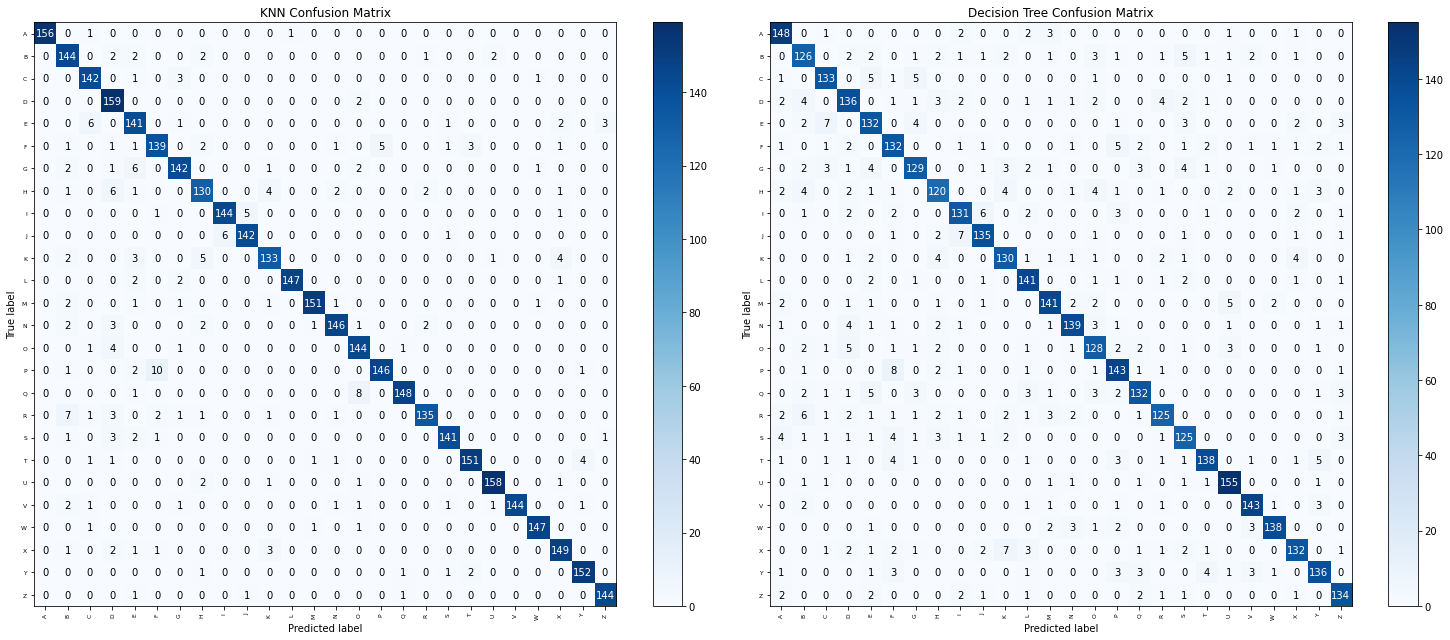

In [10]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Compute confusion matrices
y_pred_knn = grid_knn.predict(X_test)
y_pred_dt  = grid_dt.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_dt  = confusion_matrix(y_test, y_pred_dt)

# 2. Helper to plot one matrix
def plot_cm(cm, classes, title, ax):
    im = ax.imshow(cm, interpolation='nearest', aspect='auto', cmap='Blues')
    ax.set_title(title)
    fig = ax.get_figure()
    # color bar
    cbar = fig.colorbar(im, ax=ax)
    # tick labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=90, fontsize=6)
    ax.set_yticklabels(classes, fontsize=6)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    # annotate each cell with the count
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

# 3. Plot both side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 9))
class_names = le.classes_  # array of 'A'...'Z'

plot_cm(cm_knn, class_names, 'KNN Confusion Matrix', ax1)
plot_cm(cm_dt,  class_names, 'Decision Tree Confusion Matrix', ax2)

plt.tight_layout()
plt.show()
